# Kapitola 7: Operace s náhodnými veličinami

## 7.1 Transformace náhodných veličin

**Věta (o monotónní transformaci):**
Nechť $X$ má distribuční funkci $F_X$ a nosič $S_X$. Nechť funkce $h$ zobrazuje $S_X$ na $S_Y \subseteq \mathbb{R}$.

- Pokud $h$ je ostře rostoucí, pak distribuční funkce $Y = h(X)$ je:
$$F_Y(y) = F_X(h^{-1}(y))$$
- Pokud $h$ je ostře klesající, pak:
$$F_Y(y) = 1 - F_X(h^{-1}(y))$$

## 7.2 Transformace náhodných vektorů

**Poznámka:**
Při transformaci náhodného vektoru $\mathbf{X} = (X_1, X_2)$ pomocí funkce $\mathbf{Y} = h(\mathbf{X})$ je třeba použít Jacobian transformace.

#### Transformace náhodných veličin: Kartézské → Polární souřadnice

Mějme dvě nezávislé náhodné veličiny:
- $X \sim \mathcal{N}(0, 1)$
- $Y \sim \mathcal{N}(0, 1)$

Transformujeme je do polárních souřadnic:
- $R = \sqrt{X^2 + Y^2}$
- $\Theta = \arctan2(Y, X)$

Očekáváme:
- $R \sim$ Rayleighovo rozdělení
- $\Theta \sim$ rovnoměrné rozdělení na $[-\pi, \pi]$

interactive(children=(FloatSlider(value=0.0, description='ρ', max=0.99, min=-0.99, step=0.01), IntSlider(value…

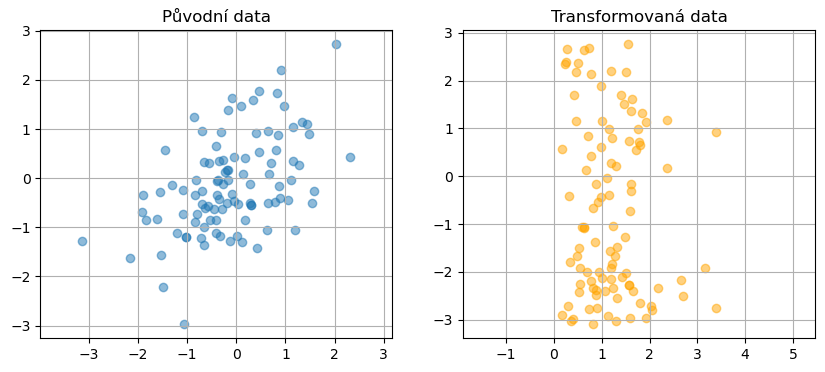

In [6]:
# Příklad: transformace dvourozměrného normálního rozdělení
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from scipy.stats import rayleigh, uniform
from ipywidgets import interact, FloatSlider, IntSlider

# Funkce pro simulaci a zobrazení histogramů polárních souřadnic

def simulace_polarni_souradnice(rho, n=10000):
    # Kovarianční matice pro danou korelaci
    cov = [[1, rho], [rho, 1]]
    mean = [0, 0]
    # Generování dat z dvourozměrného normálního rozdělení
    data =np.random.multivariate_normal(mean, cov, n)
    X, Y = data[:, 0], data[:, 1]
    # Transformace do polárních souřadnic
    R = np.sqrt(X**2 + Y**2)
    Theta = np.arctan2(Y, X)
    # Vykreslení histogramů
    plt.figure(figsize=(12, 5))
        
    plt.subplot(1, 2, 1)
    count, bins, _ = plt.hist(R, bins=50, density=True, color='skyblue', edgecolor='black', label='Simulace')
    r_vals = np.linspace(0, max(R), 500)
    rayleigh_pdf = rayleigh.pdf(r_vals, scale=1)  # scale=1 odpovídá σ=1
    plt.plot(r_vals, rayleigh_pdf, 'r-', lw=2, label='Rayleighova hustota')
    plt.title(f"Histogram R (rho = {rho:.2f})")
    plt.xlabel("R")
    plt.ylabel("Hustota")
    plt.legend()


    plt.subplot(1, 2, 2)
    count, bins, _ =plt.hist(Theta, bins=50, density=True, color='darkblue', edgecolor='black',alpha=0.5)
    uniform_pdf = uniform.pdf(bins, loc=-np.pi, scale=2*np.pi)
    plt.plot(bins, uniform_pdf, 'r-', lw=2, label='Funkce hustoty rovnoměrného rozdělení')  
    plt.title(f"Histogram Θ (rho = {rho:.2f})")
    plt.xlabel("Θ [rad]")
    plt.ylabel("Hustota")

    plt.tight_layout()
    plt.savefig("polar_histograms.png")
    plt.show()

# Příklad použití s rho = 0.8
# Interaktivní slider pro rho
interact(simulace_polarni_souradnice,
         rho=FloatSlider(min=-0.99, max=0.99, step=0.01, value=0.0, description='ρ'),
         n=IntSlider(min=100, max=10000, step=1000, value=10000, description='Náhodné vzorky:')) 
# Ukázka původních a transformovaných dat pro rho = 0.0
rho = 0.5
cov = [[1, rho], [rho, 1]]
mean = [0, 0]
n= 100
data =np.random.multivariate_normal(mean, cov, n)
X, Y = data[:, 0], data[:, 1]
# Transformace do polárních souřadnic
R = np.sqrt(X**2 + Y**2)
Theta = np.arctan2(Y, X)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(X, Y, alpha=0.5)
plt.grid(True)
plt.title('Původní data')
plt.axis('equal')

plt.subplot(1, 2, 2)
plt.scatter(R, Theta, alpha=0.5, color='orange')
plt.grid(True)  
plt.title('Transformovaná data')
plt.axis('equal')
plt.show()

## 7.3 Součet, minimum a maximum náhodných veličin

**Věta:**
Nechť $X$ a $Y$ jsou nezávislé náhodné veličiny s hustotami $f_X$ a $f_Y$. Pak hustota součtu $W = X + Y$ je:
$$f_W(w) = \int_{-\infty}^{\infty} f_X(x) f_Y(w - x) dx$$

In [7]:
# Součet dvou normálních rozdělení
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from ipywidgets import interact, FloatSlider

def zobraz_hustoty(mu1=0.0, sigma1=1.0, mu2=0.0, sigma2=1.0):
    x = np.linspace(-15, 15, 1000)

    # Hustoty původních rozdělení
    f1 = norm.pdf(x, loc=mu1, scale=sigma1)
    f2 = norm.pdf(x, loc=mu2, scale=sigma2)

    # Součet
    mu_sum = mu1 + mu2
    sigma_sum = np.sqrt(sigma1**2 + sigma2**2)
    f_sum = norm.pdf(x, loc=mu_sum, scale=sigma_sum)

    # Vykreslení
    plt.figure(figsize=(10, 6))
    plt.plot(x, f1, '--', label=f'N({mu1:.2f}, {sigma1**2:.2f})')
    plt.plot(x, f2, '--', label=f'N({mu2:.2f}, {sigma2**2:.2f})')
    plt.plot(x, f_sum, 'r', lw=2, label=f'Součet N({mu1:.2f},{sigma1**2:.2f}) + N({mu2:.2f},{sigma2**2:.2f})')
    plt.title('Hustota součtu dvou normálních veličin')
    plt.xlabel('x')
    plt.ylabel('Hustota')
    plt.legend()
    plt.grid(True)
    plt.show()

# Interaktivní ovládání
interact(zobraz_hustoty,
         mu1=FloatSlider(min=-10, max=10, step=0.5, value=0.0, description='μ₁'),
         sigma1=FloatSlider(min=0.1, max=5, step=0.1, value=1.0, description='σ₁'),
         mu2=FloatSlider(min=-10, max=10, step=0.5, value=0.0, description='μ₂'),
         sigma2=FloatSlider(min=0.1, max=5, step=0.1, value=1.0, description='σ₂'))

interactive(children=(FloatSlider(value=0.0, description='μ₁', max=10.0, min=-10.0, step=0.5), FloatSlider(val…

<function __main__.zobraz_hustoty(mu1=0.0, sigma1=1.0, mu2=0.0, sigma2=1.0)>

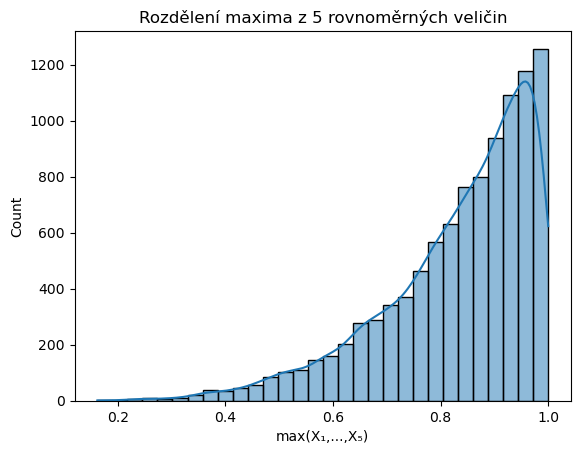

In [8]:
# Maximum z n nezávislých rovnoměrných veličin
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
n = 5
samples = np.random.uniform(0, 1, size=(10000, n))
maxima = np.max(samples, axis=1)

sns.histplot(maxima, bins=30, kde=True)
plt.title('Rozdělení maxima z 5 rovnoměrných veličin')
plt.xlabel('max(X₁,...,X₅)')
plt.show()

## 7.4 Rozdělení odvozená od normálního rozdělení

- **Chi-kvadrát rozdělení:**
$$X^2 = Z_1^2 + Z_2^2 + \dots + Z_k^2 \sim \chi^2(k)$$
- **Studentovo t-rozdělení:**
$$T = \frac{Z}{\sqrt{X^2 / k}} \sim t(k)$$

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2, t
from ipywidgets import interact, IntSlider

def simulace_chi_t(k=5, n=10000):
    # Simulace chi-kvadrát rozdělení
    X = np.random.normal(0, 1, size=(n, k))
    samples_chi = np.sum(X**2, axis=1)

    # Simulace t rozdělení
    Z = np.random.normal(0, 1, size=n)
    samples_t = Z / np.sqrt(samples_chi / k)

    # Osy pro teoretické hustoty
    x_chi = np.linspace(0, np.max(samples_chi), 500)
    x_t = np.linspace(np.min(samples_t), np.max(samples_t), 500)

    chi_pdf = chi2.pdf(x_chi, df=k)
    t_pdf = t.pdf(x_t, df=k)

    # Vykreslení
    plt.figure(figsize=(12, 5))

    # Chi-kvadrát
    plt.subplot(1, 2, 1)
    plt.hist(samples_chi, bins=30, density=True, color='skyblue', edgecolor='black', alpha=0.7)
    plt.plot(x_chi, chi_pdf, 'r-', lw=2, label='Teorie')
    plt.title(f'Chi-kvadrát rozdělení (df = {k})')
    plt.xlabel('x')
    plt.ylabel('Hustota')
    plt.legend()

    # t rozdělení
    plt.subplot(1, 2, 2)
    plt.hist(samples_t, bins=30, density=True, color='salmon', edgecolor='black', alpha=0.7)
    plt.plot(x_t, t_pdf, 'r-', lw=2, label='Teorie')
    plt.title(f'Studentovo t rozdělení (df = {k})')
    plt.xlabel('x')
    plt.ylabel('Hustota')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Interaktivní ovládání
interact(simulace_chi_t,
         k=IntSlider(min=1, max=30, step=1, value=5, description='Stupně volnosti'),
         n=IntSlider(min=100, max=10000, step=100, value=1000, description='Počet vzorků'))

interactive(children=(IntSlider(value=5, description='Stupně volnosti', max=30, min=1), IntSlider(value=1000, …

<function __main__.simulace_chi_t(k=5, n=10000)>

## 7.5 Limitní věty a zákony velkých čísel

**Centrální limitní věta:**
Nechť $X_1, X_2, \dots, X_n$ jsou i.i.d. s $\mathbb{E}[X_i] = \mu$ a $\mathrm{Var}(X_i) = \sigma^2$. Pak:
$$\frac{\sum_{i=1}^n X_i - n\mu}{\sqrt{n}\sigma} \xrightarrow{D} N(0,1)$$

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from ipywidgets import interact, IntSlider, Dropdown
def simulate_means(distribution='exponential', sample_size=30, num_samples=1000):
    if distribution == 'uniform':
        data = np.random.uniform(0, 1, (num_samples, sample_size))
    elif distribution == 'exponential':
        data = np.random.exponential(1, (num_samples, sample_size))
    elif distribution == 'normal':
        data = np.random.normal(0, 1, (num_samples, sample_size))
    else:
        raise ValueError("Neznámé rozdělení")

    means = data.mean(axis=1)

    plt.figure(figsize=(10, 6))
    count, bins, ignored = plt.hist(means, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black')

    # Teoretická normální křivka
    mu, sigma = np.mean(means), np.std(means)
    x = np.linspace(min(bins), max(bins), 1000)
    plt.plot(x, norm.pdf(x, mu, sigma), 'r-', lw=2, label='Normální aproximace')

    plt.title(f'Histogram průměrů ({distribution}, n={sample_size})')
    plt.xlabel('Průměr')
    plt.ylabel('Hustota')
    plt.legend()
    plt.grid(True)
    plt.show()

interact(simulate_means,
         distribution=Dropdown(options=['uniform', 'exponential', 'normal'], value='exponential', description='Rozdělení:'),
         sample_size=IntSlider(value=30, min=1, max=100, step=1, description='Velikost vzorku:'),
         num_samples=IntSlider(value=1000, min=100, max=5000, step=100, description='Počet simulací:'))


interactive(children=(Dropdown(description='Rozdělení:', index=1, options=('uniform', 'exponential', 'normal')…

<function __main__.simulate_means(distribution='exponential', sample_size=30, num_samples=1000)>